<a href="https://colab.research.google.com/github/lakshyasahu111/Sentiment-Analyzer-Using-RNN-and-LSTM/blob/main/Sentiment_Analyser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Project Description**
In This Project we will mainly be creating a `Sentiment-Analyzer` using `RNN`
The dataset we wil be taking of `imdb` that consist of 50000 data points

The project overview is


1.   Firstly Training with Vanilla RNN
2.   Making Some Optimzations.
3.   Using LSTMs


and taking a look on the Accuracies and Loss of `Vanilla RNN` without any optimzation.

Then we will we moving on training the same dataset on `LSTM`


#Importing Libraries





In [123]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

## Loading Dataset

In [124]:
from datasets import load_dataset
dataset = load_dataset("imdb")

train_texts = dataset['train']['text']
train_labels = dataset['train']['label']

test_texts = dataset['test']['text']
test_labels = dataset['test']['label']


In [125]:
dataset.shape

{'train': (25000, 2), 'test': (25000, 2), 'unsupervised': (50000, 2)}

In [126]:
dataset['train'][1],dataset['train'][3]

({'text': '"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn\'t matter what one\'s political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn\'t true. I\'ve seen R-rated films with male nudity. Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas and flapping labia? Nowhere, because they don\'t exist. The same goes for those crappy cable shows: schlongs swinging in the breeze but not a clitoris in sight. And those pretentious indie movies like The Brown Bunny, in which we\'re treated to the site of Vincent Gallo\'s throbbing johnson, but not a trace of pink visible on Chloe Sevigny. Before crying (or implying) "double-standard" in matters of nudity, the mentally obtuse should take into account one unavoidably obvious anatomical difference between men and women: there are no genitals on display when actresses appears nude,

##Building Vocabulary

In [127]:
from collections import Counter
import re

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())
def build_vocab(texts, max_size=10000):
    words = []
    for text in texts:
        words.extend(tokenize(text))
    freq = Counter(words)
    vocab = {word: i+1 for i, (word, _) in enumerate(freq.most_common(max_size))}
    return vocab

vocab = build_vocab(train_texts, max_size=5000)

In [128]:
def encode(text, vocab, max_len=200):
    tokens = tokenize(text)
    idxs = [vocab.get(token, 0) for token in tokens]  # 0 for unknown words
    if len(idxs) < max_len:
        idxs += [0] * (max_len - len(idxs))
    else:
        idxs = idxs[:max_len]
    return idxs

In [129]:
#  Precompute encodings (DO THIS ONCE)

train_encoded = [encode(text, vocab) for text in train_texts]
test_encoded  = [encode(text, vocab) for text in test_texts]

## Encoding Text

In [130]:
encode('crime',vocab,1) #Gives the tensor which is one for 'crime and 0 at all other vocabs or gives the index of text in vocab

[814]

In [131]:

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx], self.vocab), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_dataset = TextDataset(train_texts, train_labels, vocab)
test_dataset = TextDataset(test_texts, test_labels, vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

## RNN Module

In [132]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=50, hidden_dim=64, output_dim=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

##Loss Optimzer

In [133]:

model =RNNClassifier(len(vocab))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

#Creating Models and Evaluating

In [134]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()

        # better loss calculation
        total_loss += loss.item() * x_batch.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    accuracy = correct / total
    avg_loss = total_loss / total

    return avg_loss, accuracy

In [135]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)

            # better loss calculation
            total_loss += loss.item() * x_batch.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    accuracy = correct / total
    avg_loss = total_loss / total

    return avg_loss, accuracy

In [136]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

RNNClassifier(
  (embedding): Embedding(5001, 50, padding_idx=0)
  (rnn): RNN(50, 64, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

In [137]:

epochs = 10
train_losses,val_losses = [],[]
train_accs,val_accs = [],[]
for epoch in range(epochs):
    train_loss,train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train loss={train_loss:.4f}, Train acc={train_acc:.4f}, Val loss={val_loss:.4f}, Val acc={val_acc:.4f}")

Epoch 1: Train loss=0.7031, Train acc=0.4934, Val loss=0.6944, Val acc=0.4963
Epoch 2: Train loss=0.6941, Train acc=0.5067, Val loss=0.6941, Val acc=0.5045
Epoch 3: Train loss=0.6922, Train acc=0.5161, Val loss=0.6940, Val acc=0.5058
Epoch 4: Train loss=0.6896, Train acc=0.5249, Val loss=0.6952, Val acc=0.5070
Epoch 5: Train loss=0.6866, Train acc=0.5328, Val loss=0.6981, Val acc=0.5054
Epoch 6: Train loss=0.6833, Train acc=0.5440, Val loss=0.6992, Val acc=0.5110
Epoch 7: Train loss=0.6781, Train acc=0.5466, Val loss=0.6999, Val acc=0.5097
Epoch 8: Train loss=0.6730, Train acc=0.5547, Val loss=0.7056, Val acc=0.5113
Epoch 9: Train loss=0.6652, Train acc=0.5692, Val loss=0.7093, Val acc=0.5166
Epoch 10: Train loss=0.6596, Train acc=0.5744, Val loss=0.7122, Val acc=0.5232


In [138]:
train_accs,val_accs,train_losses,val_losses


([0.49344,
  0.50668,
  0.51612,
  0.52492,
  0.5328,
  0.544,
  0.54664,
  0.55468,
  0.56924,
  0.5744],
 [0.49628,
  0.50448,
  0.50584,
  0.50696,
  0.5054,
  0.51104,
  0.50972,
  0.51132,
  0.51664,
  0.52316],
 [0.7031201770401001,
  0.6940507005310058,
  0.6921737017631531,
  0.6895959911727906,
  0.6865580032348633,
  0.6833450908088684,
  0.6781132618331909,
  0.6730091180419921,
  0.6651864542007446,
  0.6595949402427673],
 [0.6944009551429748,
  0.6940665340232849,
  0.6940401697921753,
  0.6952044839668274,
  0.6980877830314636,
  0.6992207808494568,
  0.699940675868988,
  0.7055554767227172,
  0.709349221458435,
  0.7122128002738952])

In [139]:
## Model Accuracies And Losses
Train_Accuracy=max(train_accs)
Val_Accuracy=max(val_accs)
Train_Loss=min(train_losses)
Val_Loss=min(val_losses)
print(f"Train Accuracy: {Train_Accuracy}")
print(f"Validation Accuracy: {Val_Accuracy}")
print(f"Train Loss: {Train_Loss}")
print(f"Validation Loss: {Val_Loss}")

Train Accuracy: 0.5744
Validation Accuracy: 0.52316
Train Loss: 0.6595949402427673
Validation Loss: 0.6940401697921753


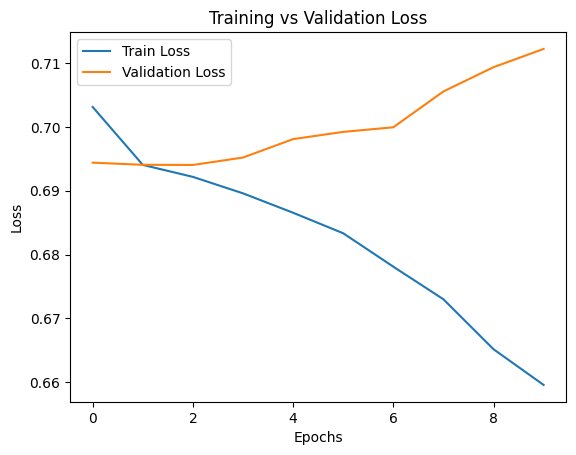

In [140]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [141]:
def predict_sentiment(text, model, vocab, device):
    model.eval()

    # Encode text
    encoded = encode(text, vocab)
    tensor = torch.tensor(encoded).unsqueeze(0).to(device)  # add batch dim

    with torch.no_grad():
        output = model(tensor)
        prediction = torch.argmax(output, dim=1).item()

    return "Positive" if prediction == 1 else "Negative"

In [142]:
text = "It is the most worst movie ever!"
print(predict_sentiment(text, model, vocab, device))

Positive


In [143]:
import torch.nn.functional as F

def predict_with_confidence(text, model, vocab, device):
    model.eval()

    encoded = encode(text, vocab)
    tensor = torch.tensor(encoded).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = F.softmax(output, dim=1)

    pred = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred].item()

    label = "Positive" if pred == 1 else "Negative"
    return label, confidence

In [144]:
test_texts[0]

'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as they have

In [156]:
import random
score=0
for i in range(10):
    idx = random.randint(0, len(test_texts) - 1)

    sample_text = test_texts[idx]
    actual_label = test_labels[idx]

    predicted = predict_with_confidence(sample_text, model, vocab, device)
    actual = "Positive" if actual_label == 1 else "Negative"
    print("Review:", sample_text[:10000])  # first 200 chars
    print("Actual:", "Positive" if actual_label == 1 else "Negative")
    print("Predicted:", predicted)
    if(predicted[0]!=actual):
      print("Wrong")
    else:
      print("Correct")
      score+=1
    print()

print(f"Score is {score} out of 10"  )

Review: I can't believe that I actually sat thru this entire film. A friend rented it because the jacket made it sound good. In it's defense, the jacket was correct; there was a supposed haunted room that someone slept in overnight. From the jacket, it sounded like this was on par with Freddy, Jason, or maybe "The Shining." It couldn't be farther from the truth.<br /><br />If you are a fan of minimalist and/or surrealist films, you may enjoy it. If you're looking for a good fright movie, or a couple of thrills, go rent Jason vs Freddy IV -- you'll have a much better night.
Actual: Negative
Predicted: ('Negative', 0.8173258900642395)
Correct

Review: My only regret is that one cannot grade a movie on IMDb with a 0. "A Cena..." would definitely deserve that! At LEAST.<br /><br />*SPOILER?* The movie starts with a bunch of people entering a crypt to awaken an ancient Vampire. When a guy cuts himself and his blood drips and falls onto the putrid and dried corpse that is supposed to be a bl

Upto This part our training consist of simple RNN without any hidden layer.
Certain Results can be attributed .
These are


1.   Validation Accuracies=`val_accs`
2.   Training Accuracies=`train_accs`
3.   Validation Loss=`val loss`
4.   Training Loss=`train_loss`

This becomes our source of Reference to compare upto which degree we can optimize our model using further Techniques




# Using **LSTM**

In [146]:
class RNNClassifierUsingLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=200, hidden_dim=64, output_dim=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(
                    input_size=embed_dim,
                    hidden_size=hidden_dim,
                    num_layers=2,
                    dropout=0.3,
                    bidirectional=True,
                    batch_first=True
                )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

In [147]:

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts   # already encoded
        self.labels = labels
    def __len__(self):
     return len(self.texts)
    def __getitem__(self, idx):
        x = torch.tensor(self.texts[idx])
        y = torch.tensor(self.labels[idx])
        return x, y

train_dataset = TextDataset(train_encoded, train_labels)
test_dataset  = TextDataset(test_encoded, test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [148]:
model =RNNClassifierUsingLSTM(len(vocab))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [149]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

RNNClassifierUsingLSTM(
  (embedding): Embedding(5001, 200, padding_idx=0)
  (rnn): LSTM(200, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [150]:

epochs = 10
train_losses,val_losses = [],[]
train_accs,val_accs = [],[]
for epoch in range(epochs):
    train_loss,train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train loss={train_loss:.4f}, Val loss={val_loss:.4f}, Val acc={val_acc:.4f}")

Epoch 1: Train loss=0.6920, Val loss=0.6933, Val acc=0.5049
Epoch 2: Train loss=0.6809, Val loss=0.6673, Val acc=0.6132
Epoch 3: Train loss=0.6440, Val loss=0.6309, Val acc=0.6698
Epoch 4: Train loss=0.6351, Val loss=0.6110, Val acc=0.6737
Epoch 5: Train loss=0.5986, Val loss=0.6420, Val acc=0.6408
Epoch 6: Train loss=0.5642, Val loss=0.5693, Val acc=0.7318
Epoch 7: Train loss=0.5205, Val loss=0.5549, Val acc=0.7415
Epoch 8: Train loss=0.4759, Val loss=0.5138, Val acc=0.7491
Epoch 9: Train loss=0.4224, Val loss=0.5418, Val acc=0.7602
Epoch 10: Train loss=0.4266, Val loss=0.5830, Val acc=0.7125


In [151]:
## Model Accuracies And Losses
Train_Accuracy=max(train_accs)
Val_Accuracy=max(val_accs)
Train_Loss=min(train_losses)
Val_Loss=min(val_losses)
print(f"Train Accuracy: {Train_Accuracy}")
print(f"Validation Accuracy: {Val_Accuracy}")
print(f"Train Loss: {Train_Loss}")
print(f"Validation Loss: {Val_Loss}")

Train Accuracy: 0.81764
Validation Accuracy: 0.76016
Train Loss: 0.42241712518692015
Validation Loss: 0.5137791242218017


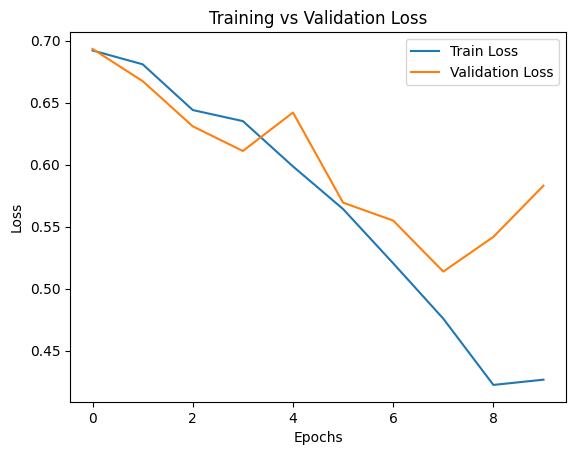

In [152]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [153]:
def predict_sentiment(text, model, vocab, device):
    model.eval()

    # Encode text
    encoded = encode(text, vocab)
    tensor = torch.tensor(encoded).unsqueeze(0).to(device)  # add batch dim

    with torch.no_grad():
        output = model(tensor)
        prediction = torch.argmax(output, dim=1).item()

    return "Positive" if prediction == 1 else "Negative"

In [154]:
import torch.nn.functional as F

def predict_with_confidence(text, model, vocab, device):
    model.eval()

    encoded = encode(text, vocab)
    tensor = torch.tensor(encoded).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = F.softmax(output, dim=1)

    pred = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred].item()

    label = "Positive" if pred == 1 else "Negative"
    return label, confidence

In [155]:
import random
score=0
for i in range(10):
    idx = random.randint(0, len(test_texts) - 1)

    sample_text = test_texts[idx]
    actual_label = test_labels[idx]

    predicted = predict_with_confidence(sample_text, model, vocab, device)
    actual = "Positive" if actual_label == 1 else "Negative"
    print("Review:", sample_text[:10000])  # first 200 chars
    print("Actual:", "Positive" if actual_label == 1 else "Negative")
    print("Predicted:", predicted)
    if(predicted[0]!=actual):
      print("Wrong")
    else:
      print("Correct")
      score+=1
    print()

print(f"Score is {score} out of 10"  )

Review: I know these types of films sell tickets and make a profit for the film makers but it just won't do as a film about Vietnam. Viet Nam was filled with horrors for the men who lived it day in and day out.<br /><br />This film stars Gene Hackman who is Korean war vet assigned to train a group of rag-tag Viet Nam Vets for a return trip to that country to rescue a group of American POW's held at a camp there. These men include a former tunnel rat, a crazy acid dropping sailor, a blond tanned surfer from California and some inexperienced kid (Patrick Swayze) who just so happens had a dad that was killed in Nam. They train first at some camp in Texas and once in Nam they are found out and lose all their weapons. They are able to find replacement weapons and continue on their way to free the captured men. Most of the men are found and saved but the rag-tag group is mostly wiped out.<br /><br />This movie played like a video game in which you could figure out what was going to happen ne

#Conclusion
It is Evident that using LSTM has significantly our model and increased its accuracy.
The Contrast can be clearly depicted as

**In Simple RNN**


    1.   Train Accuracy: 0.5744
    2.   Validation Accuracy: 0.52316
    3.   Train Loss: 0.6595949402427673
    4.   Validation Loss: 0.6940401697921753


**Using LSTM**


    1.   Train Accuracy: 0.81764
    2.   Validation Accuracy: 0.76016
    3.   Train Loss: 0.42241712518692015
    4.   Validation Loss: 0.5137791242218017






*There is a clear difference in accuracies and losses in using different methods which suggest that LSTM far outweighs simple RNN*.







